### Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import os

### Paths & Constans

In [2]:
# Base path — all other paths derive from this
BASE_DIR  = r"C:\Users\RAJA\Desktop\DA\Projects\FailSafe\backend\ml"
DATA_DIR  = os.path.join(BASE_DIR, "data")
MAT_PATH  = os.path.join(DATA_DIR, "student-mat.csv")
POR_PATH  = os.path.join(DATA_DIR, "student-por.csv")

# 13-column merge key (same as student-merge.R)
MERGE_KEY = [
    "school", "sex", "age", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason", "nursery", "internet"
]

# Columns that need encoding
BINARY_COLS  = [
    "school", "sex", "address", "famsize", "Pstatus",
    "schoolsup", "famsup", "paid", "activities",
    "nursery", "higher", "internet", "romantic"
]
NOMINAL_COLS = ["Mjob", "Fjob", "reason", "guardian"]

print("Paths set ✓")

Paths set ✓


#### CSV files

In [5]:
mat = pd.read_csv(MAT_PATH, sep=";")
por = pd.read_csv(POR_PATH, sep=";")

print(f"Math shape      : {mat.shape}")
print(f"Portuguese shape: {por.shape}")

Math shape      : (395, 33)
Portuguese shape: (649, 33)


In [6]:
# Using Portuguese dataset (649 students)
# Largest single dataset, better distribution for risk modeling
df = por.copy()
print(f"Working dataset shape: {df.shape}")
df.head(3)

Working dataset shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12


### Adding risk labels

In [7]:
# Binary: 1 = at-risk (G3 < 10), 0 = not at-risk
df["risk_binary"] = (df["G3"] < 10).astype(int)

# 3-class: 0 = Low (0-9), 1 = Medium (10-14), 2 = High (15-20)
df["risk_level"] = pd.cut(
    df["G3"],
    bins=[-1, 9, 14, 20],
    labels=[0, 1, 2]
).astype(int)

print(f"At-risk students : {df['risk_binary'].sum()} out of {len(df)} ({df['risk_binary'].mean()*100:.1f}%)")
print(f"\nRisk level distribution:")
print(df["risk_level"].value_counts().sort_index().rename({0:"Low (0-9)", 1:"Medium (10-14)", 2:"High (15-20)"}))

At-risk students : 100 out of 649 (15.4%)

Risk level distribution:
risk_level
Low (0-9)         100
Medium (10-14)    418
High (15-20)      131
Name: count, dtype: int64


### Basic EDA: dataset overview

In [10]:
print(f"Shape          : {df.shape}")
print(f"Total students : {len(df)}")
print(f"\nColumn types:")
print(df.dtypes.value_counts())
print(f"\nNumerical columns  : {list(df.select_dtypes(include='number').columns)}")
print(f"\nCategorical columns: {list(df.select_dtypes(include='str').columns)}")

Shape          : (649, 35)
Total students : 649

Column types:
int64    18
str      17
Name: count, dtype: int64

Numerical columns  : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'risk_binary', 'risk_level']

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


### Missing values check

In [11]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
})

# Only show columns that actually have missing values
missing_df = missing_df[missing_df["Missing Count"] > 0]

if len(missing_df) == 0:
    print("No missing values found in any column ✓")
else:
    print(missing_df)

No missing values found in any column ✓


### Descriptive statistics for numerical columns

In [12]:
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 
            'failures', 'famrel', 'freetime', 'goout', 
            'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

df[num_cols].describe().round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,16.74,2.51,2.31,1.57,1.93,0.22,3.93,3.18,3.18,1.50,2.28,3.54,3.66,11.40,11.57,11.91
std,1.22,1.13,1.10,0.75,0.83,0.59,0.96,1.05,1.18,0.92,1.28,1.45,4.64,2.75,2.91,3.23
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,2.00,0.00,10.00,10.00,10.00
50%,17.00,2.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,12.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,32.00,19.00,19.00,19.00


### Categorical columns distribution

In [14]:
cat_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
            'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup',
            'famsup', 'paid', 'activities', 'nursery',
            'higher', 'internet', 'romantic']

for col in cat_cols:
    counts = df[col].value_counts()
    pcts   = (counts / len(df) * 100).round(1)
    print(f"\n{col}:")
    for val, cnt, pct in zip(counts.index, counts.values, pcts.values):
        print(f"  {val:<12} {cnt:>4}  ({pct}%)")


school:
  GP            423  (65.2%)
  MS            226  (34.8%)

sex:
  F             383  (59.0%)
  M             266  (41.0%)

address:
  U             452  (69.6%)
  R             197  (30.4%)

famsize:
  GT3           457  (70.4%)
  LE3           192  (29.6%)

Pstatus:
  T             569  (87.7%)
  A              80  (12.3%)

Mjob:
  other         258  (39.8%)
  services      136  (21.0%)
  at_home       135  (20.8%)
  teacher        72  (11.1%)
  health         48  (7.4%)

Fjob:
  other         367  (56.5%)
  services      181  (27.9%)
  at_home        42  (6.5%)
  teacher        36  (5.5%)
  health         23  (3.5%)

reason:
  course        285  (43.9%)
  home          149  (23.0%)
  reputation    143  (22.0%)
  other          72  (11.1%)

guardian:
  mother        455  (70.1%)
  father        153  (23.6%)
  other          41  (6.3%)

schoolsup:
  no            581  (89.5%)
  yes            68  (10.5%)

famsup:
  yes           398  (61.3%)
  no            251  (38.7%)

paid:

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean consistent style throughout
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Visualization libraries ready ✓")

Visualization libraries ready ✓


#### Grade distribution (G1, G2, G3)

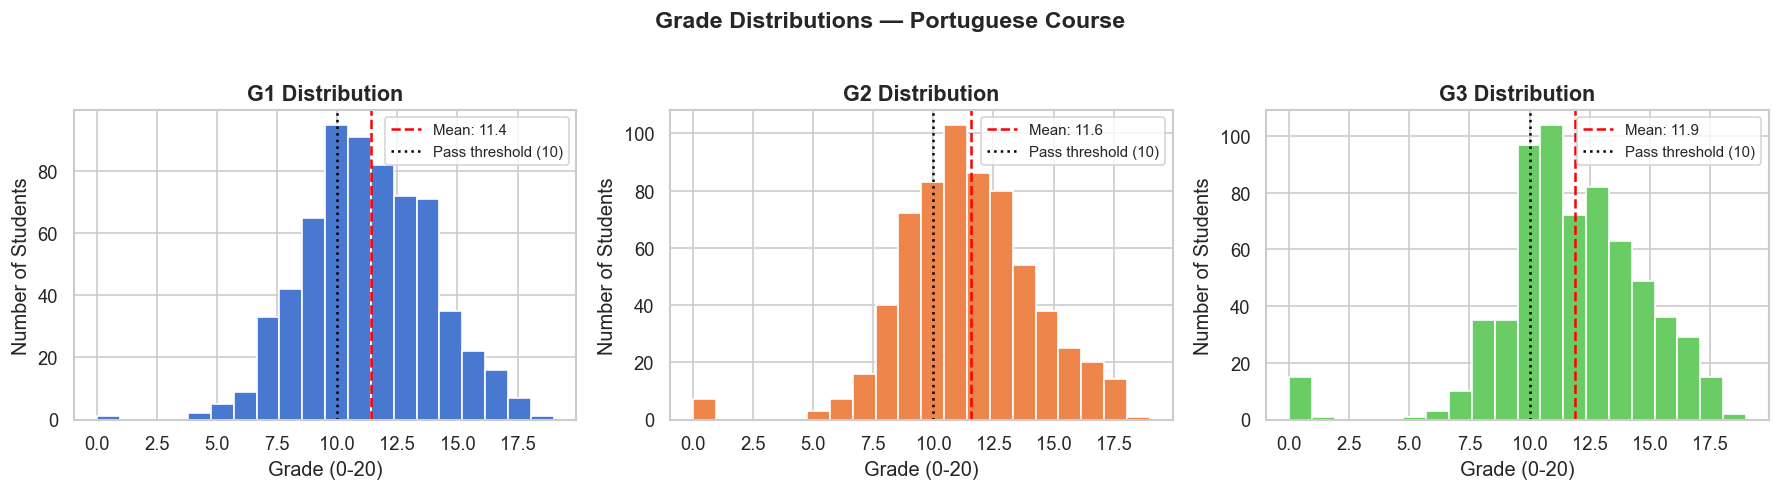

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(["G1", "G2", "G3"]):
    axes[i].hist(df[col], bins=20, color=sns.color_palette("muted")[i], edgecolor="white")
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean: {df[col].mean():.1f}")
    axes[i].axvline(10, color="black", linestyle=":", linewidth=1.5, label="Pass threshold (10)")
    axes[i].set_title(f"{col} Distribution", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Grade (0-20)")
    axes[i].set_ylabel("Number of Students")
    axes[i].legend(fontsize=9)

plt.suptitle("Grade Distributions — Portuguese Course", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

####  Risk label distribution

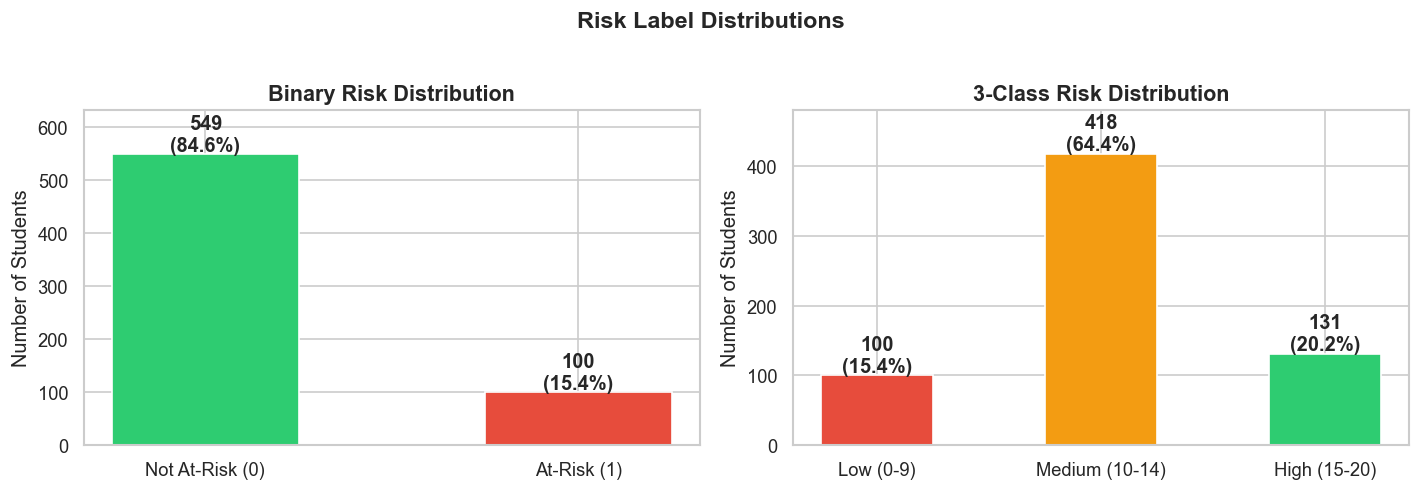

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Binary risk
binary_counts = df["risk_binary"].value_counts().sort_index()
axes[0].bar(["Not At-Risk (0)", "At-Risk (1)"],
            binary_counts.values,
            color=["#2ecc71", "#e74c3c"],
            edgecolor="white", width=0.5)
for i, v in enumerate(binary_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontweight="bold")
axes[0].set_title("Binary Risk Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Students")
axes[0].set_ylim(0, max(binary_counts.values) * 1.15)

# 3-class risk
level_counts = df["risk_level"].value_counts().sort_index()
axes[1].bar(["Low (0-9)", "Medium (10-14)", "High (15-20)"],
            level_counts.values,
            color=["#e74c3c", "#f39c12", "#2ecc71"],
            edgecolor="white", width=0.5)
for i, v in enumerate(level_counts.values):
    axes[1].text(i, v + 5, f"{v}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontweight="bold")
axes[1].set_title("3-Class Risk Distribution", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Students")
axes[1].set_ylim(0, max(level_counts.values) * 1.15)

plt.suptitle("Risk Label Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Correlation heatmap

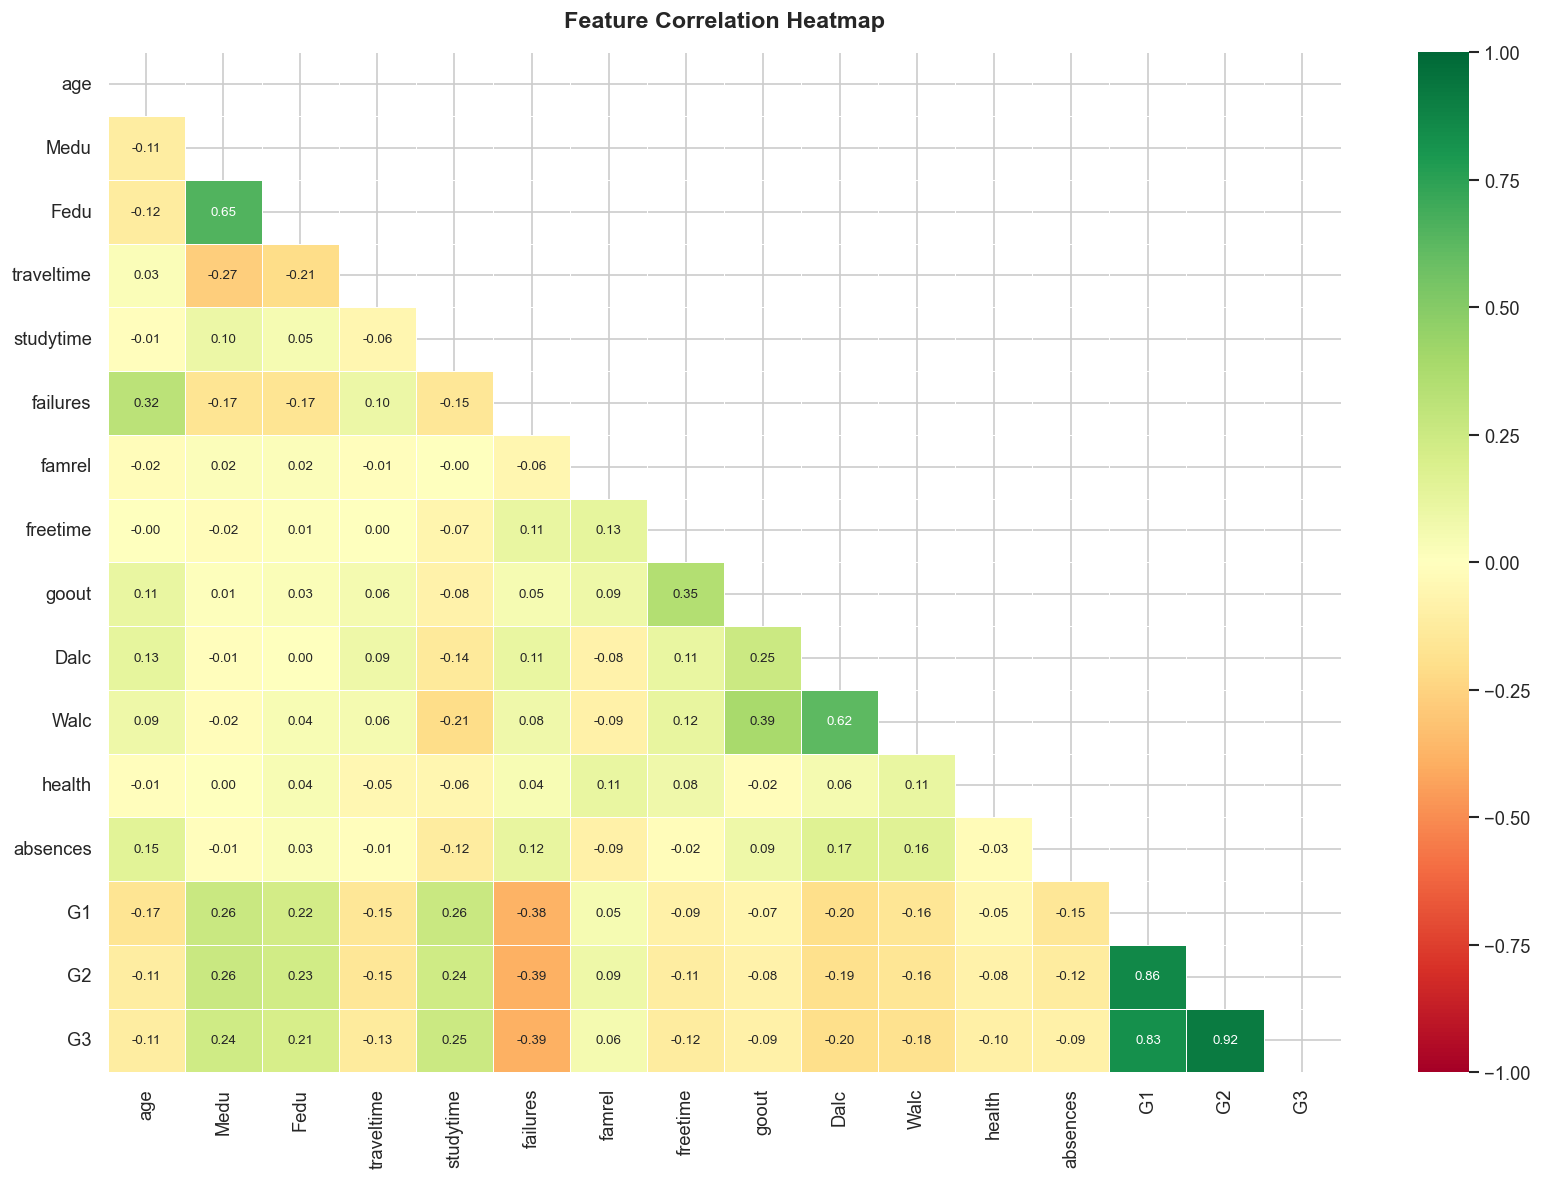

In [20]:
fig, ax = plt.subplots(figsize=(14, 10))

num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime',
            'failures', 'famrel', 'freetime', 'goout',
            'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

corr_matrix = df[num_cols].corr().round(2)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)

ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### Top feature correlations with G3 (bar chart)

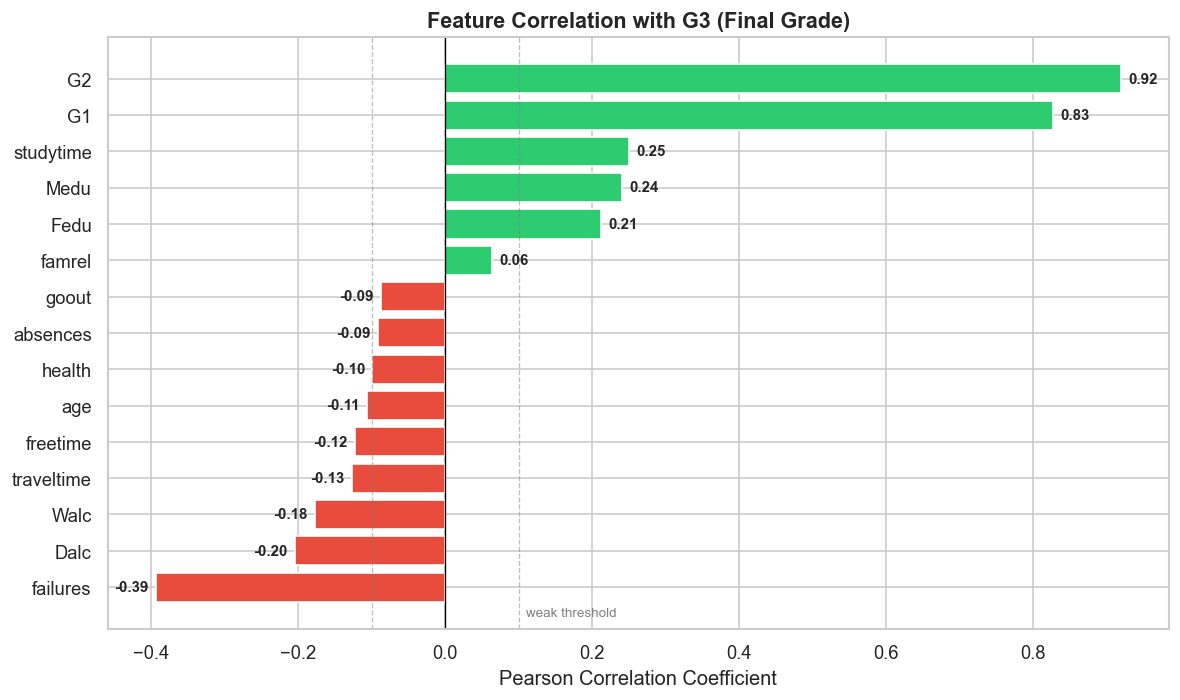

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

# Correlation of all numeric features with G3, sorted
g3_corr = df[num_cols].corr()["G3"].drop("G3").sort_values()

colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in g3_corr.values]

bars = ax.barh(g3_corr.index, g3_corr.values, color=colors, edgecolor="white")

# Value labels on bars
for bar, val in zip(bars, g3_corr.values):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9, fontweight="bold"
    )

ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.1,  color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(-0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Feature Correlation with G3 (Final Grade)", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation Coefficient")
ax.text(0.11, -0.8, "weak threshold", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

### Outlier detection (boxplots)

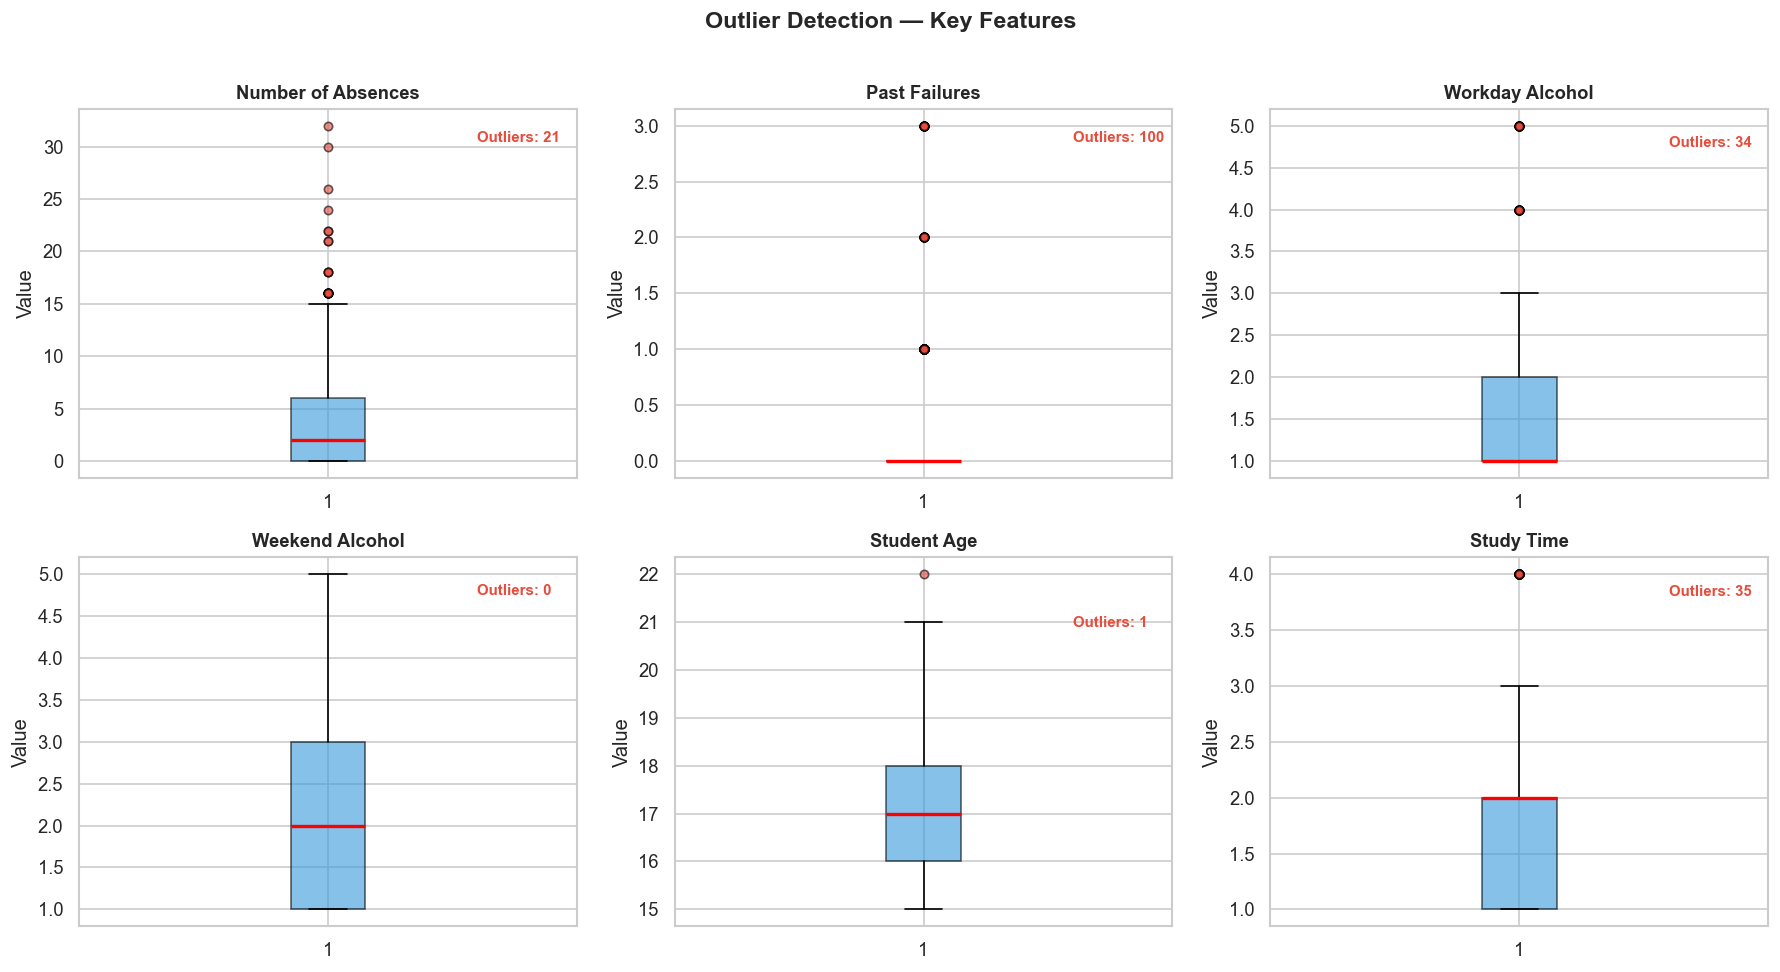

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

outlier_cols = {
    "absences"  : "Number of Absences",
    "failures"  : "Past Failures",
    "Dalc"      : "Workday Alcohol",
    "Walc"      : "Weekend Alcohol",
    "age"       : "Student Age",
    "studytime" : "Study Time"
}

for ax, (col, label) in zip(axes.flatten(), outlier_cols.items()):
    ax.boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor="#3498db", alpha=0.6),
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker="o", markerfacecolor="#e74c3c",
                        markersize=5, alpha=0.6)
    )
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    ax.set_title(f"{label}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Value")
    ax.text(1.3, df[col].max() * 0.95,
            f"Outliers: {len(outliers)}",
            fontsize=9, color="#e74c3c", fontweight="bold")

plt.suptitle("Outlier Detection — Key Features", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Caping absences outliers only

In [23]:
# Cap absences at 95th percentile
# Why 95th and not IQR: we have only 649 rows,
# IQR would remove too many valid at-risk students
cap_value = df["absences"].quantile(0.95)
print(f"Absences 95th percentile cap : {cap_value}")
print(f"Before — max: {df['absences'].max()},  "
      f"mean: {df['absences'].mean():.2f}")

df["absences"] = df["absences"].clip(upper=cap_value)

print(f"After  — max: {df['absences'].max()},  "
      f"mean: {df['absences'].mean():.2f}")
print("\nAbsences outlier capping done ✓")

Absences 95th percentile cap : 12.0
Before — max: 32,  mean: 3.66
After  — max: 12,  mean: 3.38

Absences outlier capping done ✓


### Categorical features vs risk (visual)

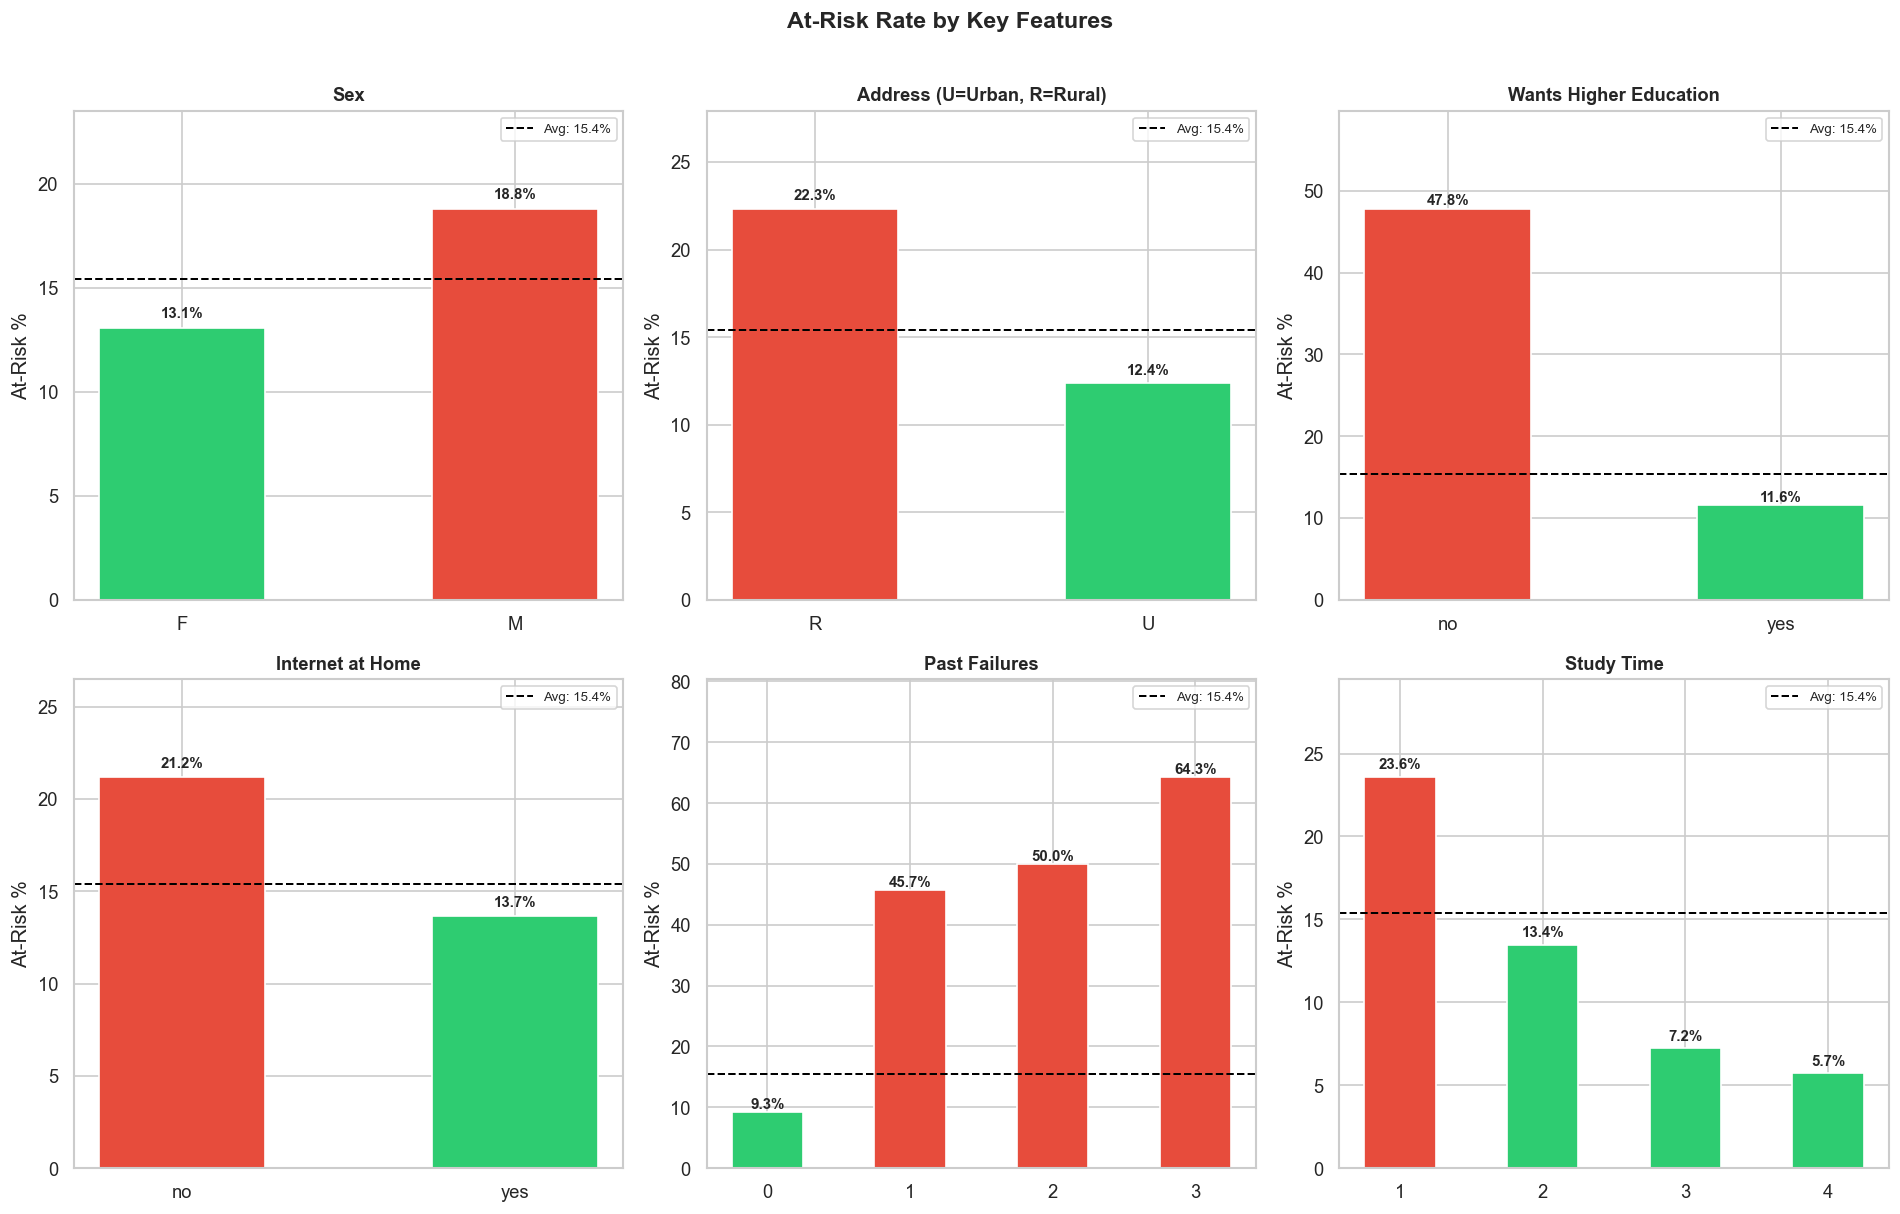

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cat_risk_cols = {
    "sex"      : "Sex",
    "address"  : "Address (U=Urban, R=Rural)",
    "higher"   : "Wants Higher Education",
    "internet" : "Internet at Home",
    "failures" : "Past Failures",
    "studytime": "Study Time"
}

for ax, (col, label) in zip(axes.flatten(), cat_risk_cols.items()):
    risk_rate = df.groupby(col)["risk_binary"].mean() * 100
    bars = ax.bar(
        risk_rate.index.astype(str),
        risk_rate.values,
        color=["#e74c3c" if v > 15 else "#2ecc71" for v in risk_rate.values],
        edgecolor="white", width=0.5
    )
    for bar, val in zip(bars, risk_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.5, f"{val:.1f}%",
                ha="center", fontsize=9, fontweight="bold")
    ax.axhline(df["risk_binary"].mean() * 100,
               color="black", linestyle="--",
               linewidth=1.2, label=f"Avg: {df['risk_binary'].mean()*100:.1f}%")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylabel("At-Risk %")
    ax.set_ylim(0, max(risk_rate.values) * 1.25)
    ax.legend(fontsize=8)

plt.suptitle("At-Risk Rate by Key Features", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### G1/G2 vs risk scatter (grade trajectory)

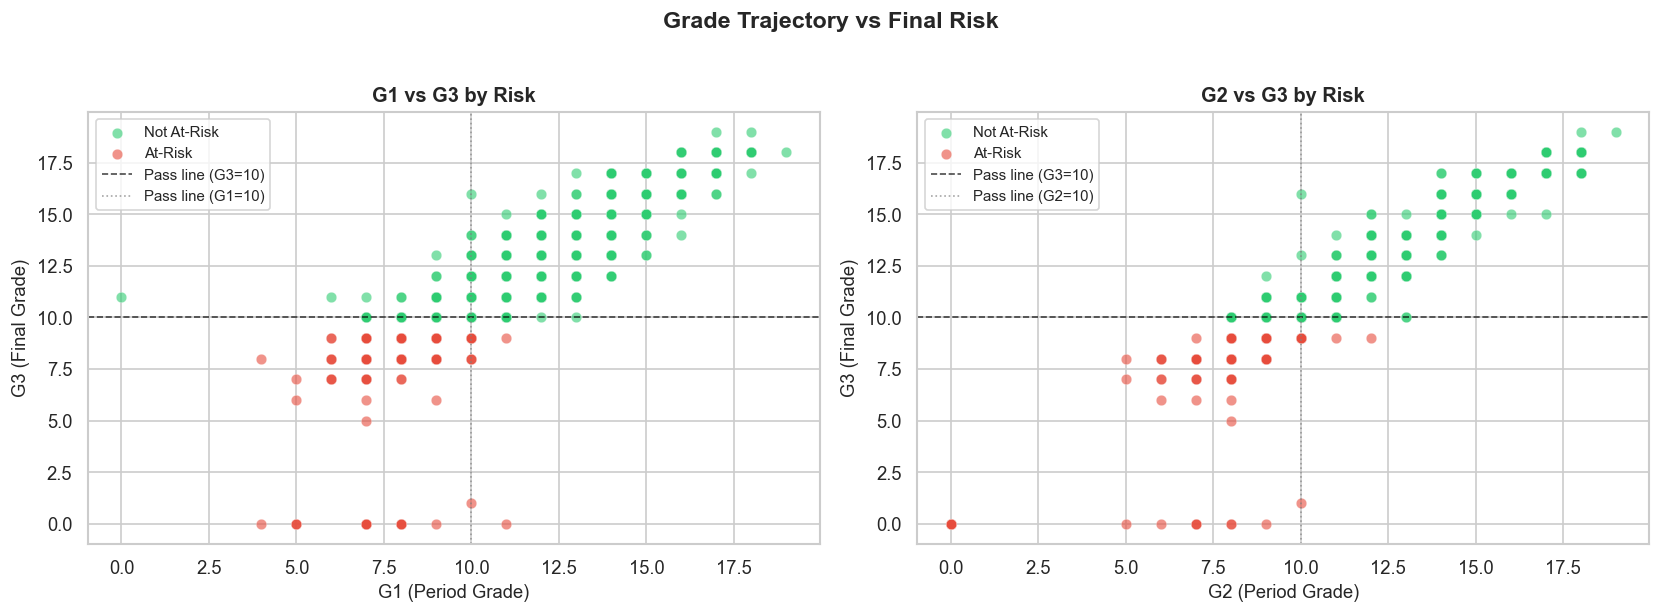

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = df["risk_binary"].map({0: "#2ecc71", 1: "#e74c3c"})
labels = df["risk_binary"].map({0: "Not At-Risk", 1: "At-Risk"})

for ax, (xcol, ycol) in zip(axes, [("G1", "G3"), ("G2", "G3")]):
    for risk_val, color, label in [(0, "#2ecc71", "Not At-Risk"),
                                    (1, "#e74c3c", "At-Risk")]:
        mask = df["risk_binary"] == risk_val
        ax.scatter(
            df.loc[mask, xcol],
            df.loc[mask, ycol],
            c=color, label=label,
            alpha=0.6, edgecolors="white",
            linewidth=0.3, s=40
        )
    ax.axhline(10, color="black", linestyle="--",
               linewidth=1, alpha=0.7, label="Pass line (G3=10)")
    ax.axvline(10, color="gray", linestyle=":",
               linewidth=1, alpha=0.7, label=f"Pass line ({xcol}=10)")
    ax.set_xlabel(f"{xcol} (Period Grade)", fontsize=11)
    ax.set_ylabel("G3 (Final Grade)", fontsize=11)
    ax.set_title(f"{xcol} vs G3 by Risk", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Grade Trajectory vs Final Risk",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Final feature selection + encoding

In [26]:
# Dropping weak correlators: health, famrel, freetime, traveltime
# Keeping all others including weak-but-contextual ones (Dalc, Walc, absences)
# because they matter for intervention recommendations even if correlation is low

DROP_COLS = ["G3", "risk_binary", "risk_level", "health", "famrel", 
             "freetime", "traveltime"]

df_model = df.copy()

# Encode binary yes/no columns → 0/1
for col in BINARY_COLS:
    if col in df_model.columns:
        df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Encode nominal columns → integer codes
for col in NOMINAL_COLS:
    if col in df_model.columns:
        df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Split features and target
X = df_model.drop(columns=DROP_COLS, errors="ignore")
y = df["risk_binary"]

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"At-risk count        : {y.sum()} ({y.mean()*100:.1f}%)")
print(f"\nFinal features used:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

Feature matrix shape : (649, 28)
Target shape         : (649,)
At-risk count        : 100 (15.4%)

Final features used:
   1. school
   2. sex
   3. age
   4. address
   5. famsize
   6. Pstatus
   7. Medu
   8. Fedu
   9. Mjob
  10. Fjob
  11. reason
  12. guardian
  13. studytime
  14. failures
  15. schoolsup
  16. famsup
  17. paid
  18. activities
  19. nursery
  20. higher
  21. internet
  22. romantic
  23. goout
  24. Dalc
  25. Walc
  26. absences
  27. G1
  28. G2


### Feature scaling

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [28]:
# Only scale continuous columns
# Ordinal/binary columns don't need scaling for tree-based models
# BUT we scale everything for consistency since we may add
# logistic regression as a baseline comparison later

SCALE_COLS = ["age", "Medu", "Fedu", "studytime", "failures",
              "goout", "Dalc", "Walc", "absences", "G1", "G2"]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[SCALE_COLS] = scaler.fit_transform(X[SCALE_COLS])

print("Scaling done ✓")
print(f"\nSample scaled values (first 3 rows):")
print(X_scaled[SCALE_COLS].head(3).round(3))

Scaling done ✓

Sample scaled values (first 3 rows):
     age   Medu   Fedu  studytime  failures  goout   Dalc   Walc  absences  \
0  1.032  1.310  1.541      0.084    -0.374  0.694 -0.544 -0.998     0.166   
1  0.210 -1.336 -1.189      0.084    -0.374 -0.157 -0.544 -0.998    -0.368   
2 -1.433 -1.336 -1.189      0.084    -0.374 -1.009  0.539  0.561     0.700   

      G1     G2  
0 -4.155 -0.196  
1 -0.875 -0.196  
2  0.219  0.491  


### Train/test split

In [29]:
# Stratified split to preserve 15.4% at-risk ratio in both sets
# 80/20 split — with 649 rows this gives us 519 train, 130 test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # critical with imbalanced classes
)

print(f"Training set   : {X_train.shape}")
print(f"Test set       : {X_test.shape}")
print(f"\nClass distribution in train:")
print(y_train.value_counts().rename({0:"Not At-Risk", 1:"At-Risk"}))
print(f"\nClass distribution in test:")
print(y_test.value_counts().rename({0:"Not At-Risk", 1:"At-Risk"}))
print(f"\nAt-risk % in train : {y_train.mean()*100:.1f}%")
print(f"At-risk % in test  : {y_test.mean()*100:.1f}%")

Training set   : (519, 28)
Test set       : (130, 28)

Class distribution in train:
risk_binary
Not At-Risk    439
At-Risk         80
Name: count, dtype: int64

Class distribution in test:
risk_binary
Not At-Risk    110
At-Risk         20
Name: count, dtype: int64

At-risk % in train : 15.4%
At-risk % in test  : 15.4%


#### Create models directory + save preprocessing artifacts

In [61]:
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# Save scaler
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.pkl"))

# Re-fit encoders properly and save each one individually
# so the API can load and use them independently
encoders = {}

df_temp = df.copy()

for col in BINARY_COLS:
    if col in df_temp.columns:
        le = LabelEncoder()
        le.fit(df_temp[col].astype(str))
        encoders[col] = le

for col in NOMINAL_COLS:
    if col in df_temp.columns:
        le = LabelEncoder()
        le.fit(df_temp[col].astype(str))
        encoders[col] = le

# Save everything
joblib.dump(encoders,  os.path.join(MODELS_DIR, "encoders.pkl"))

# Save column metadata
metadata = {
    "feature_cols" : list(X_train.columns),
    "scale_cols"   : SCALE_COLS,
    "drop_cols"    : DROP_COLS,
    "binary_cols"  : BINARY_COLS,
    "nominal_cols" : NOMINAL_COLS,
    "merge_key"    : MERGE_KEY,
    "risk_bins"    : {"low": [0, 9], "medium": [10, 14], "high": [15, 20]},
    "target"       : "risk_binary",
    "threshold"    : 10
}
joblib.dump(metadata, os.path.join(MODELS_DIR, "metadata.pkl"))

print("Preprocessing artifacts saved ✓")
print(f"\nSaved files:")
for f in os.listdir(MODELS_DIR):
    size = os.path.getsize(os.path.join(MODELS_DIR, f))
    print(f"  {f:<25} {size/1024:.1f} KB")

Encoders and metadata saved ✓

Saved files:
  encoders.pkl              4.2 KB
  feature_cols.pkl          0.3 KB
  metadata.pkl              0.8 KB
  rf_model.pkl              1111.3 KB
  scaler.pkl                1.1 KB
  shap_explainer.pkl        728.2 KB
  shap_values_test.pkl      14.4 KB
  xgb_model.pkl             256.0 KB
